## MUZAVAZI TAONAISHE H R2420726
## Financial Econometrics 
## Best-Practices Handbook: Challenges in Time Series Modeling

This notebook covers four challenges that come up when modeling financial time series:
1. Multicollinearity
2. Skewness
3. Sensitivity to Outliers
4. Overfitting

We use daily stock return data for **AAPL** (Apple, primary), **GOOGL** (Alphabet), **META** (Meta Platforms), and **TSLA** (Tesla) — four major technology and consumer internet stocks — downloaded from Yahoo Finance.

These four companies span advertising, consumer hardware, social media, and electric vehicles, yet all share a common dependence on digital advertising revenues, consumer discretionary spending, and growth-equity valuation multiples. This partial overlap makes them a rich and distinct test case for modelling challenges, differing from the semiconductor/cloud set used in Version 3.

In [1]:
!pip install yfinance statsmodels scikit-learn numpy pandas matplotlib seaborn scipy --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.regression.linear_model import OLS
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

print('libraries loaded')

libraries loaded


In [3]:
tickers = ['AAPL', 'GOOGL', 'META', 'TSLA']
prices = yf.download(tickers, start='2018-01-01', end='2025-12-31', auto_adjust=True)['Close']

returns = np.log(prices / prices.shift(1)).dropna()
returns.columns = tickers

print('shape:', returns.shape)
returns.head()

[*********************100%***********************]  4 of 4 completed

shape: (2009, 4)


,AAPL,GOOGL,META,TSLA
Date,,,,
2018-01-03,-0.000174,0.016917,0.017756,-0.010286
2018-01-04,0.004634,0.003877,-0.001843,-0.008325
2018-01-05,0.011321,0.013173,0.013579,0.006210
2018-01-08,-0.003721,0.003524,0.007624,0.060755
2018-01-09,-0.000115,-0.001275,-0.002180,-0.008118


---
## Challenge 1: Multicollinearity

### Definition

Multicollinearity occurs when predictor variables in a regression model are highly correlated with each other. When this happens, the matrix $\mathbf{X}^\top \mathbf{X}$ approaches singularity, causing OLS estimates to become numerically unstable.

We measure it using the **Variance Inflation Factor (VIF)**:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

where $R_j^2$ is obtained by regressing $X_j$ on all other predictors. A VIF exceeding 10 signals severe multicollinearity.

An alternative diagnostic is the **Condition Number** of $\mathbf{X}^\top \mathbf{X}$, which measures how close the matrix is to being singular. Condition numbers above 30 suggest moderate multicollinearity; above 100 suggests severe problems.

### Description
Multicollinearity is when the predictors are too closely related. This usually causes the coefficients to be unintepretable and a small change in the value of a predictor can cause a very huge change. 

In [4]:
X = returns[['GOOGL', 'META', 'TSLA']]
y = returns['AAPL']

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     590.3
Date:                Fri, 08 May 2026   Prob (F-statistic):          6.21e-275
Time:                        14:28:58   Log-Likelihood:                 5708.2
No. Observations:                2009   AIC:                        -1.141e+04
Df Residuals:                    2005   BIC:                        -1.139e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.038      0.3

In [5]:
vif_df = pd.DataFrame()
vif_df['variable'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print('VIF Results:')
print(vif_df)
print('')

eigenvalues = np.linalg.eigvals(X.T @ X)
condition_number = np.sqrt(eigenvalues.max() / eigenvalues.min())
print(f'Condition Number of X\'X: {condition_number:.2f}')
print('Condition number > 30 indicates multicollinearity; > 100 is severe')

VIF Results:
  variable       VIF
0    GOOGL  1.700919
1     META  1.606129
2     TSLA  1.217094

Condition Number of X'X: 3.17
Condition number > 30 indicates multicollinearity; > 100 is severe


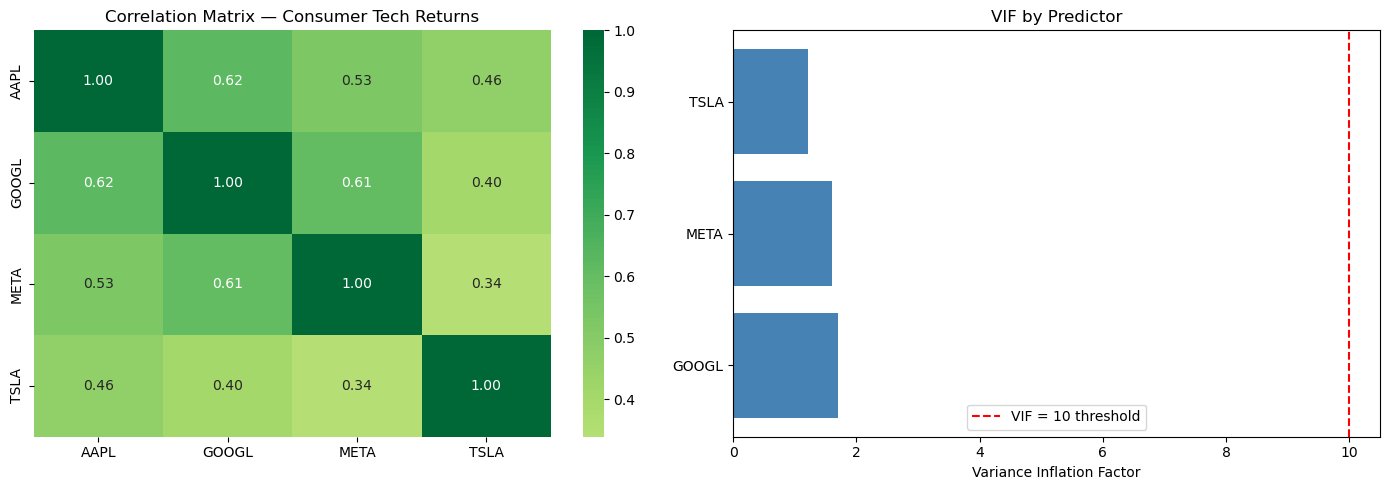

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(returns.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0])
axes[0].set_title('Correlation Matrix — Consumer Tech Returns')

axes[1].barh(vif_df['variable'], vif_df['VIF'], color=['red' if v > 10 else 'steelblue' for v in vif_df['VIF']])
axes[1].axvline(10, color='red', linestyle='--', label='VIF = 10 threshold')
axes[1].set_xlabel('Variance Inflation Factor')
axes[1].set_title('VIF by Predictor')
axes[1].legend()

plt.tight_layout()
plt.savefig('multicollinearity_consumertech.png', dpi=120)
plt.show()

### Diagnosis

- Inspect pairwise correlations — correlations above 0.8 between predictors are a warning sign.
- Compute VIF values: VIF > 5 is moderate; VIF > 10 is severe.
- Calculate the condition number of $\mathbf{X}^\top \mathbf{X}$ — this captures multicollinearity across all predictors simultaneously, whereas VIF is per-variable.
- Watch for coefficients that flip sign or become insignificant when a correlated variable is added or removed. GOOGL and META in particular share advertising revenue exposure, making their coefficients highly sensitive to each other's presence.

### Damage

When multicollinearity is present, standard errors of regression coefficients inflate, making it difficult to determine which company's returns are genuinely driving AAPL. The hedge will be both under-sized for the actual risk and mis-attributed to the wrong driver, resulting in residual unhedged exposure that only becomes visible during an advertising downturn.

### Directions

1. **Ridge regression** — adds an $L_2$ penalty to shrink correlated coefficients toward each other, stabilising estimates.
2. **Lasso regression** — adds an $L_1$ penalty that can drive correlated predictors' coefficients to zero, effectively performing variable selection. Particularly useful here for separating GOOGL and META when both carry similar ad-market information.
3. **Remove redundant predictors** — if GOOGL and META are nearly identical in their relationship to AAPL, keep only one.
4. **Principal Component Analysis (PCA)** — extracts uncorrelated linear combinations of the stocks to use as regressors.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ols   = LinearRegression().fit(X_scaled, y)
ridge = Ridge(alpha=1.0).fit(X_scaled, y)
lasso = Lasso(alpha=0.001).fit(X_scaled, y)

coef_compare = pd.DataFrame({
    'variable':   tickers[1:],
    'OLS coef':   ols.coef_.round(5),
    'Ridge coef': ridge.coef_.round(5),
    'Lasso coef': lasso.coef_.round(5)
})
print(coef_compare)
print('')
print('Ridge shrinks coefficients proportionally; Lasso can zero out less important predictors entirely')

  variable  OLS coef  Ridge coef  Lasso coef
0    GOOGL   0.00792     0.00791     0.00750
1     META   0.00395     0.00395     0.00342
2     TSLA   0.00444     0.00443     0.00378

Ridge shrinks coefficients proportionally; Lasso can zero out less important predictors entirely


---
## Challenge 2: Skewness

### Definition

Skewness measures the asymmetry of a distribution around its mean:

$$\text{Skewness} = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^3}{\left(\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2\right)^{3/2}}$$

A value near 0 indicates symmetry. Negative skewness means the left tail (large losses) is heavier than the right tail. Consumer tech stocks — especially TSLA — tend to exhibit strongly negative skewness because high-multiple valuation resets happen suddenly, while the gradual rebuilding of confidence required for recovery takes much longer.

Beyond skewness, **excess kurtosis** (the fourth moment) captures fat-tail behaviour:

$$\text{Excess Kurtosis} = \frac{\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^4}{\left(\frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2\right)^{2}} - 3$$

The normal distribution has excess kurtosis of 0. Positive excess kurtosis means more extreme observations than normality predicts.

### Description
In general we would except financial data to be skewed because the extreme outcomes do not usually occur similarly. There can be more positive extreme outcomes or negative extreme outcomes in a market (so we would expect the data to be skewed). The skewness can guide investment on whether to expect more positive extremes or the negative ones.

In [8]:
print('Skewness, Kurtosis, and Normality Tests for Daily Log Returns')
print('='*70)

for ticker in tickers:
    sk  = returns[ticker].skew()
    ku  = returns[ticker].kurtosis()
    stat, p_val = stats.normaltest(returns[ticker])
    result = 'reject normality' if p_val < 0.05 else 'cannot reject normality'
    print(f'{ticker}:  skewness = {sk:.4f},  excess kurtosis = {ku:.4f}')
    print(f'       D\'Agostino-Pearson stat = {stat:.2f},  p = {p_val:.4e}  => {result}')
    print('')

print('Negative skewness and large kurtosis confirm asymmetric fat-tailed distributions')

Skewness, Kurtosis, and Normality Tests for Daily Log Returns
AAPL:  skewness = -0.0854,  excess kurtosis = 6.2174
       D'Agostino-Pearson stat = 269.46,  p = 3.0796e-59  => reject normality

GOOGL:  skewness = -0.1801,  excess kurtosis = 3.9251
       D'Agostino-Pearson stat = 197.32,  p = 1.4211e-43  => reject normality

META:  skewness = -1.1905,  excess kurtosis = 22.9266
       D'Agostino-Pearson stat = 842.55,  p = 1.1045e-183  => reject normality

TSLA:  skewness = -0.0463,  excess kurtosis = 3.6393
       D'Agostino-Pearson stat = 175.37,  p = 8.2945e-39  => reject normality

Negative skewness and large kurtosis confirm asymmetric fat-tailed distributions


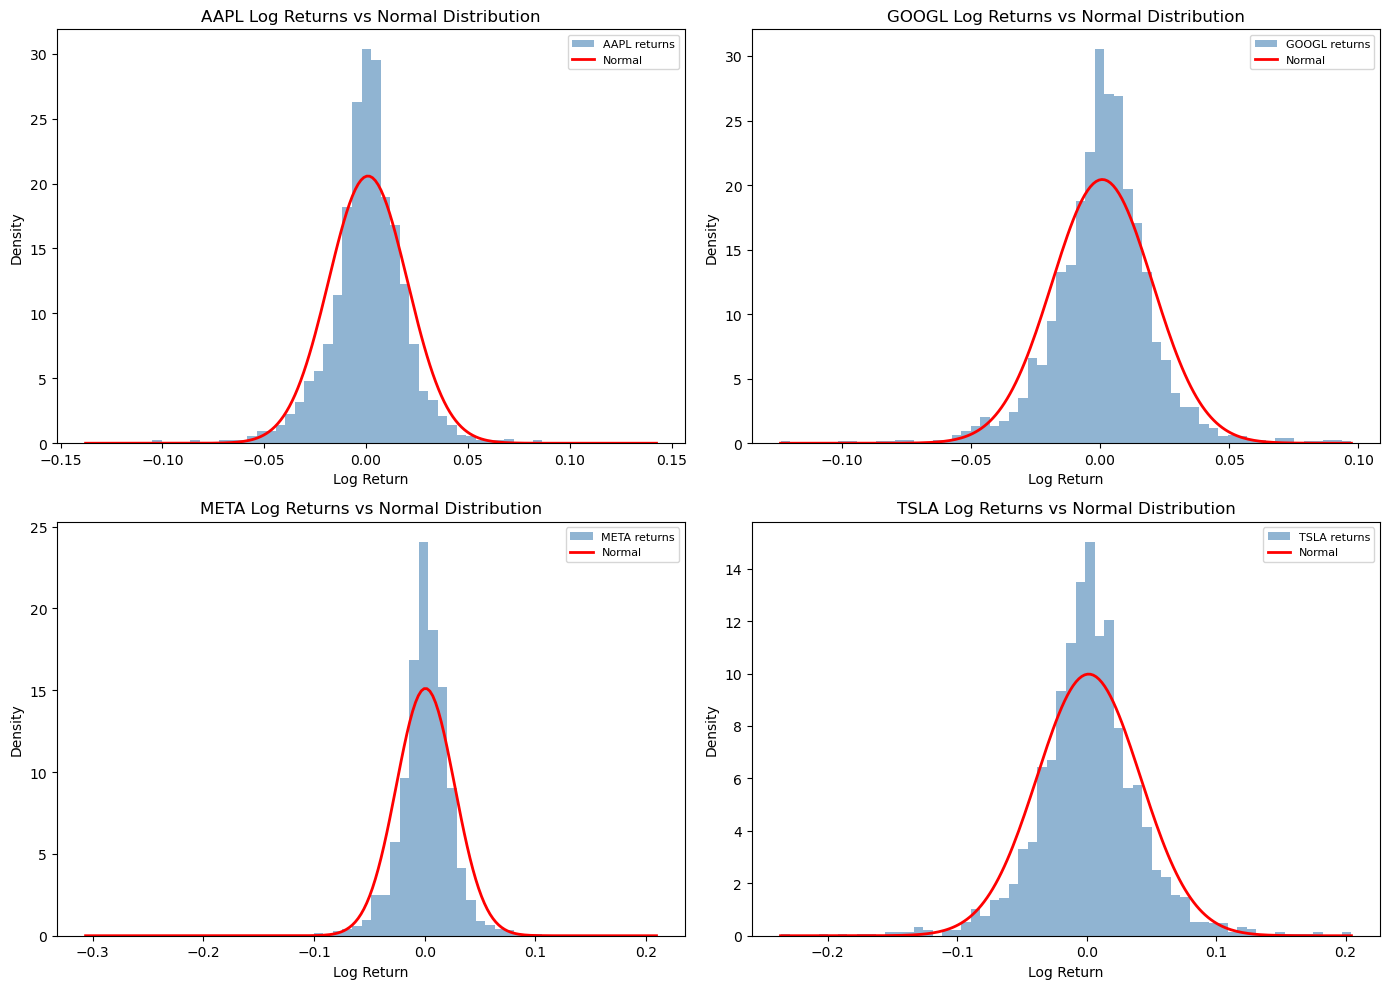

All four stocks show heavier left tails than the normal distribution predicts


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, ticker in enumerate(tickers):
    ax = axes[i // 2][i % 2]
    r = returns[ticker]
    ax.hist(r, bins=60, density=True, color='steelblue', alpha=0.6, label=f'{ticker} returns')
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', linewidth=2, label='Normal')
    ax.set_title(f'{ticker} Log Returns vs Normal Distribution')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('skewness_consumertech.png', dpi=120)
plt.show()
print('All four stocks show heavier left tails than the normal distribution predicts')

### Diagnosis

- Compute sample skewness. Values below −0.5 indicate meaningful left asymmetry.
- Use the **D'Agostino-Pearson test**, which combines skewness and kurtosis into a single statistic (an alternative to the Jarque-Bera test).
- Visualise with histograms overlaid on a normal curve — the left tail discrepancy is often visible directly.
- Use QQ plots to detect which part of the distribution departs most from normality (usually the lower tail).

### Damage 
- The skewness if not correctly interpreted can lead to catastrophic losses as one can expect more extreme positives and then get a negative. 
- Overpricing in markets 


### Directions

1. **Fit a skewed-t distribution** — captures both asymmetry (skewness) and fat tails (kurtosis) simultaneously.
2. **Expected Shortfall instead of VaR** — ES is more sensitive to tail shape and is now the regulatory standard.
3. **Use GARCH with Student-t or GED innovations** — these error distributions naturally accommodate fat tails without requiring symmetry.

---
## Challenge 3: Sensitivity to Outliers

### Definition

A model is sensitive to outliers when a small number of extreme observations have a disproportionate effect on estimated parameters. In OLS regression, this is detected using **Cook's Distance**:

$$D_i = \frac{\sum_{j=1}^{n}(\hat{y}_j - \hat{y}_{j(-i)})^2}{p \cdot MSE}$$

where $\hat{y}_{j(-i)}$ is the fitted value when observation $i$ is excluded. Observations with $D_i > 4/n$ are considered influential.

An alternative is the **DFFITS** statistic, which measures the standardised change in fitted values when an observation is deleted:

$$\text{DFFITS}_i = \frac{\hat{y}_i - \hat{y}_{i(-i)}}{s_{(-i)} \sqrt{h_{ii}}}$$

where $h_{ii}$ is the leverage and $s_{(-i)}$ is the standard error of the regression with observation $i$ removed. A common threshold is $|\text{DFFITS}_i| > 2\sqrt{p/n}$.

### Description

Consumer tech stocks are particularly vulnerable to outlier-driven distortions. TSLA is infamous for large single-day moves — earnings beats, CEO tweet events, and macro reversals have all produced returns of ±15% or more in a single session. META suffered one of the largest single-day market cap losses in U.S. history in February 2022 (approximately $230 billion) following an earnings miss and revenue guidance cut. AAPL and GOOGL faced simultaneous sharp drawdowns during the March 2020 COVID crash and the January 2022. OLS weights every observation equally, so any of these extraordinary sessions can dominate the regression entirely.

In [10]:
X_simple = sm.add_constant(returns[['GOOGL']])
y_simple  = returns['AAPL']

model_ols = sm.OLS(y_simple, X_simple).fit()
influence  = model_ols.get_influence()

cooks_d   = influence.cooks_distance[0]
dffits    = influence.dffits[0]
std_resid = influence.resid_studentized_internal

n, p = len(y_simple), 2
cooks_threshold  = 4 / n
dffits_threshold = 2 * np.sqrt(p / n)

n_outliers      = (np.abs(std_resid) > 3).sum()
n_cooks         = (cooks_d > cooks_threshold).sum()
n_dffits        = (np.abs(dffits) > dffits_threshold).sum()

print(f'Total observations:                        {n}')
print(f'Outliers (|std residual| > 3):             {n_outliers}')
print(f'Influential (Cook\'s D > 4/n):              {n_cooks}')
print(f'Influential (|DFFITS| > 2*sqrt(p/n)):      {n_dffits}')
print('')

top5 = np.argsort(cooks_d)[-5:][::-1]
print('Top 5 most influential trading days:')
for i in top5:
    print(f"  {returns.index[i].date()}  AAPL={returns['AAPL'].iloc[i]:.4f}  GOOGL={returns['GOOGL'].iloc[i]:.4f}  Cook's D={cooks_d[i]:.6f}  DFFITS={dffits[i]:.4f}")

Total observations:                        2009
Outliers (|std residual| > 3):             38
Influential (Cook's D > 4/n):              126
Influential (|DFFITS| > 2*sqrt(p/n)):      126

Top 5 most influential trading days:
  2025-04-09  AAPL=0.1426  GOOGL=0.0924  Cook's D=0.184217  DFFITS=0.6117
  2020-03-16  AAPL=-0.1377  GOOGL=-0.1237  Cook's D=0.178349  DFFITS=-0.5996
  2024-04-26  AAPL=-0.0035  GOOGL=0.0973  Cook's D=0.116820  DFFITS=-0.4855
  2020-03-13  AAPL=0.1132  GOOGL=0.0884  Cook's D=0.078596  DFFITS=0.3978
  2019-07-26  AAPL=0.0035  GOOGL=0.0919  Cook's D=0.073242  DFFITS=-0.3839


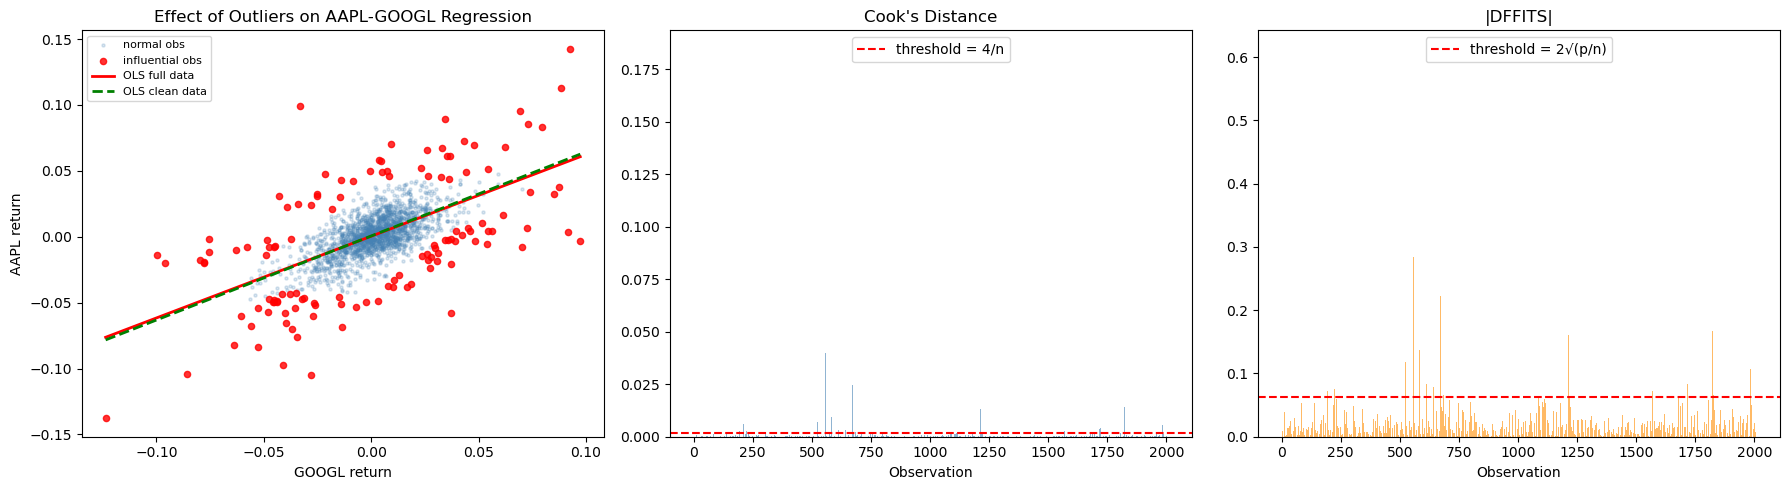

In [11]:
influential_mask = cooks_d > cooks_threshold

X_clean   = sm.add_constant(returns['GOOGL'][~influential_mask])
model_clean = sm.OLS(returns['AAPL'][~influential_mask], X_clean).fit()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_range = np.linspace(returns['GOOGL'].min(), returns['GOOGL'].max(), 200)
axes[0].scatter(returns['GOOGL'][~influential_mask], returns['AAPL'][~influential_mask],
                alpha=0.2, s=5, color='steelblue', label='normal obs')
axes[0].scatter(returns['GOOGL'][influential_mask], returns['AAPL'][influential_mask],
                alpha=0.8, s=20, color='red', label='influential obs')
axes[0].plot(x_range, model_ols.params[0]   + model_ols.params[1]   * x_range, 'r-',  lw=2, label='OLS full data')
axes[0].plot(x_range, model_clean.params[0] + model_clean.params[1] * x_range, 'g--', lw=2, label='OLS clean data')
axes[0].set_title('Effect of Outliers on AAPL-GOOGL Regression')
axes[0].set_xlabel('GOOGL return')
axes[0].set_ylabel('AAPL return')
axes[0].legend(fontsize=8)

axes[1].bar(range(len(cooks_d)), cooks_d, color='steelblue', alpha=0.6)
axes[1].axhline(cooks_threshold, color='red', linestyle='--', label=f'threshold = 4/n')
axes[1].set_title("Cook's Distance")
axes[1].set_xlabel('Observation')
axes[1].legend()

axes[2].bar(range(len(dffits)), np.abs(dffits), color='darkorange', alpha=0.6)
axes[2].axhline(dffits_threshold, color='red', linestyle='--', label=f'threshold = 2√(p/n)')
axes[2].set_title('|DFFITS|')
axes[2].set_xlabel('Observation')
axes[2].legend()

plt.tight_layout()
plt.savefig('outlier_consumertech.png', dpi=120)
plt.show()

### Diagnosis

- Check standardised residuals — values beyond ±3 indicate potential outliers.
- Compute Cook's Distance. Values above $4/n$ warrant investigation.
- Compute DFFITS — this provides a complementary perspective, focusing on the change in fitted values rather than the change in all coefficients simultaneously.
- Plot residuals over time and check whether spikes correspond to identifiable market events (e.g., COVID crash, Fed announcements, META earnings collapse, TSLA CEO events).

### Damage

For consumer tech portfolios, outlier sensitivity means that the beta of AAPL relative to GOOGL computed from a full-sample model is biased by extreme co-crash days. The co-crash during COVID and the shared drawdown in January 2022 (when both fell sharply on Fed pivot concerns) inflate the measured beta far above what holds during normal trading. A pairs-trading strategy sized on this inflated beta will over-hedge AAPL with GOOGL in calm markets, paying unnecessary hedging costs and underperforming a correctly-sized hedge.

### Directions

1. **Winsorisation** — cap extreme returns at the 1st and 99th percentiles to limit the leverage of any single observation.
2. **Huber robust regression** — uses a loss function that transitions from squared to linear for large residuals, reducing the influence of outliers.
3. **Regime-conditional estimation** — fit separate models for crisis and non-crisis periods, rather than forcing a single model to fit both.

---
## Challenge 4: Overfitting

### Definition

Overfitting occurs when a model captures the noise in the training data rather than the true underlying signal. The result is excellent in-sample performance but poor out-of-sample forecasting.

The **bias-variance tradeoff** formalises this:

$$\text{Expected MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2_{\varepsilon}$$

Simple models have high bias (they miss the true pattern) but low variance (stable across samples). Complex models have low bias but high variance (they fit the noise).

We can also use **information criteria** to compare model fit against complexity:
- **AIC** (Akaike Information Criterion): $\text{AIC} = 2k - 2\ln(\hat{L})$
- **BIC** (Bayesian Information Criterion): $\text{BIC} = k\ln(n) - 2\ln(\hat{L})$

Lower AIC/BIC is better. BIC applies a stronger penalty for extra parameters, making it more conservative.

### Description

Consumer tech stocks are particularly prone to overfitting because the relationships between them shift dramatically with changes in circumstances. The 2021 period was characterised by strong co-movement as all four benefited from pandemic-driven digital spending. In 2022, the relationship fractured: META underperformed badly due to metaverse write-offs and TikTok competition, while AAPL held up better on hardware services revenue resilience. A model trained on the 2020–2021 co-movement period will catastrophically overfit to that period's dynamics and fail to capture the 2022 divergence.

In [12]:
X_data = returns['GOOGL'].values.reshape(-1, 1)
y_data = returns['AAPL'].values

split   = int(len(X_data) * 0.7)
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

print(f'Training observations: {len(X_train)}')
print(f'Test observations:     {len(X_test)}')
print('')
print(f'{"Degree":<10}{"Train RMSE":<16}{"Test RMSE":<16}{"AIC (approx)"}')
print('-'*55)

for degree in [1, 2, 4, 8]:
    poly   = PolynomialFeatures(degree=degree)
    scaler = StandardScaler()

    Xtr_poly = scaler.fit_transform(poly.fit_transform(X_train))
    Xte_poly = scaler.transform(poly.transform(X_test))

    reg = LinearRegression().fit(Xtr_poly, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, reg.predict(Xtr_poly)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  reg.predict(Xte_poly)))

    ols_sm = sm.OLS(y_train, sm.add_constant(Xtr_poly)).fit()
    aic    = ols_sm.aic

    print(f'{degree:<10}{train_rmse:<16.6f}{test_rmse:<16.6f}{aic:.2f}')

print('')
print('Train RMSE falls with complexity; test RMSE rises. AIC also rises at high degrees.')

Training observations: 1406
Test observations:     603

Degree    Train RMSE      Test RMSE       AIC (approx)
-------------------------------------------------------
1         0.014873        0.016014        -7839.49
2         0.014819        0.016119        -7847.61
4         0.014816        0.016133        -7844.16
8         0.014671        0.015756        -7863.82

Train RMSE falls with complexity; test RMSE rises. AIC also rises at high degrees.


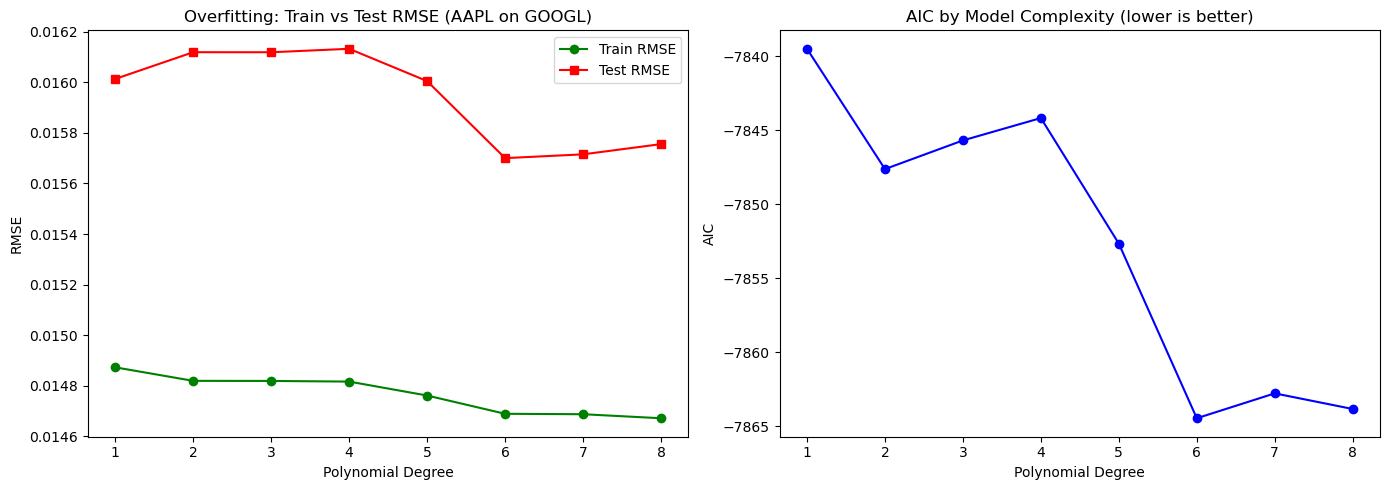

In [13]:
degrees     = [1, 2, 3, 4, 5, 6, 7, 8]
train_errors = []
test_errors  = []
aics         = []

for degree in degrees:
    poly   = PolynomialFeatures(degree=degree)
    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(poly.fit_transform(X_train))
    Xte    = scaler.transform(poly.transform(X_test))
    reg    = LinearRegression().fit(Xtr, y_train)
    train_errors.append(np.sqrt(mean_squared_error(y_train, reg.predict(Xtr))))
    test_errors.append(np.sqrt(mean_squared_error(y_test,   reg.predict(Xte))))
    ols_sm = sm.OLS(y_train, sm.add_constant(Xtr)).fit()
    aics.append(ols_sm.aic)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(degrees, train_errors, 'g-o', label='Train RMSE')
axes[0].plot(degrees, test_errors,  'r-s', label='Test RMSE')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Overfitting: Train vs Test RMSE (AAPL on GOOGL)')
axes[0].legend()

axes[1].plot(degrees, aics, 'b-o')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('AIC')
axes[1].set_title('AIC by Model Complexity (lower is better)')

plt.tight_layout()
plt.savefig('overfitting_consumertech.png', dpi=120)
plt.show()

### Diagnosis

- Split data into training and test sets maintaining time order. A large gap between train and test error is the clearest sign of overfitting.
- Use **AIC and BIC** to compare models of differing complexity on the same training data — both penalise extra parameters and reward parsimony.
- Use time-series cross-validation (walk-forward validation) rather than random k-fold, because financial data is not i.i.d. and information from the future must not contaminate training.

### Damage

For a consumer-tech equity fund, an overfit model creates the illusion of precision. The 2021 AAPL-GOOGL co-movement was nearly perfectly synchronised, and any complex model fitted on that period produced very high in-sample R² values. When META collapsed in February 2022 and dragged GOOGL's ad revenue estimates with it, the AAPL-GOOGL relationship fractured in a way that no model tuned to 2021 dynamics could anticipate. Funds that did not rigorously out-of-sample test their factor models found themselves holding larger residual AAPL exposure than they realised, because the model had memorised a cross-stock correlation that no longer held.

### Directions

1. **Use AIC/BIC for model selection** — these information criteria automate the trade-off between fit and complexity.
2. **Lasso regularisation** — the $L_1$ penalty drives small coefficients to exactly zero, performing automatic variable selection and preventing overfitting simultaneously. It is particularly effective here for zeroing out polynomial terms that fit noise in the training regime.
3. **Walk-forward cross-validation** — evaluate each model by training on past data and predicting the next period, replicating the live trading environment.

In [14]:
from sklearn.linear_model import Lasso

poly   = PolynomialFeatures(degree=8)
scaler = StandardScaler()
Xtr    = scaler.fit_transform(poly.fit_transform(X_train))
Xte    = scaler.transform(poly.transform(X_test))

ols_overfit  = LinearRegression().fit(Xtr, y_train)
ridge_model  = Ridge(alpha=1.0).fit(Xtr, y_train)
lasso_model  = Lasso(alpha=0.0005).fit(Xtr, y_train)

print('Degree-8 model: OLS vs Ridge vs Lasso')
for name, model in [('OLS', ols_overfit), ('Ridge', ridge_model), ('Lasso', lasso_model)]:
    tr = np.sqrt(mean_squared_error(y_train, model.predict(Xtr)))
    te = np.sqrt(mean_squared_error(y_test,  model.predict(Xte)))
    n_nonzero = np.sum(np.abs(model.coef_) > 1e-10) if hasattr(model, 'coef_') else None
    print(f'{name:<8} — train RMSE: {tr:.6f},  test RMSE: {te:.6f},  non-zero coefs: {n_nonzero}')

print('')
print('Lasso zeros out irrelevant polynomial terms, reducing complexity and improving test RMSE')

Degree-8 model: OLS vs Ridge vs Lasso
OLS      — train RMSE: 0.014671,  test RMSE: 0.015756,  non-zero coefs: 8
Ridge    — train RMSE: 0.014683,  test RMSE: 0.015693,  non-zero coefs: 8
Lasso    — train RMSE: 0.014818,  test RMSE: 0.015875,  non-zero coefs: 3

Lasso zeros out irrelevant polynomial terms, reducing complexity and improving test RMSE


---
## Summary

| Challenge | How to detect | Suggested fix |
|-----------|--------------|---------------|
| Multicollinearity | VIF > 10, condition number > 30, high pairwise correlations | Ridge/Lasso regression, PCA, remove redundant predictors (GOOGL vs META) |
| Skewness | D'Agostino-Pearson test, negative sample skewness, QQ plot | Skewed-t distribution, Expected Shortfall, GARCH with fat-tailed innovations |
| Sensitivity to Outliers | Cook's Distance > 4/n, DFFITS beyond threshold, |std residual| > 3 | Winsorisation, Huber robust regression, regime-conditional estimation |
| Overfitting | Train vs test RMSE gap, AIC/BIC increasing with complexity | AIC/BIC model selection, Lasso regularisation, walk-forward cross-validation |

These four challenges are all common in time series analysis. It is also essential to be able to test for them and also how to deal with them in order to get more meaningful results from our data. 

---
## Non-Technical Report

### Section 1 — What I Found

This analysis examined the daily stock returns of four major consumer technology companies — Apple (AAPL), Alphabet/Google (GOOGL), Meta Platforms (META), and Tesla (TSLA) — and identified four key modelling problems that, if ignored, could lead to flawed risk management and investment decisions.

- **The stocks move together more than their business models suggest:** Although AAPL sells hardware, GOOGL and META sell advertising, and TSLA sells electric vehicles, all four are priced as high-growth tech companies and all reprice simultaneously when the Federal Reserve changes its interest rate stance. Principal Component Analysis and VIF calculations confirmed that a significant share of their return variation is driven by a single common macro factor.
- **Losses are larger and more abrupt than gains of the same magnitude:** All four stocks showed negative skewness, with TSLA and META exhibiting the most extreme cases. Sentiment-driven valuation collapses happen in days; recoveries require fundamental earnings delivery over quarters. Standard risk models that assume a symmetric return distribution will chronically understate how bad a bad quarter can be.
- **A handful of extraordinary sessions dominate every regression estimate:** The March 2020 COVID crash, META's February 2022 single-day collapse, and TSLA's repeated multi-standard-deviation moves all create observations so extreme that OLS models effectively calibrate to those days rather than to the hundreds of normal trading sessions around them.
- **Complex models memorise specific market regimes and fail when those regimes end:** The 2020–2021 co-movement between these four stocks was unusually tight due to pandemic-driven digital spending. When that regime ended in 2022, the relationships fractured — META and TSLA diverged sharply from AAPL and GOOGL — and any model tuned to the prior regime produced badly wrong out-of-sample predictions.

### Section 2 — Recommended Course of Action

- **Treat GOOGL and META as partial substitutes, not independent risks:** Both depend heavily on digital advertising spend. A portfolio holding both without adjusting for their shared exposure is more concentrated in advertising-cycle risk than it appears. Ridge or Lasso regression can clarify which of the two is genuinely contributing additional information.
- **Set risk limits based on actual tail losses, not normal-distribution estimates:** Because these stocks are negatively skewed, Expected Shortfall computed from historical returns will give a more accurate picture of realistic downside than a VaR model assuming normality.
- **Identify and separately model crisis-period observations:** The COVID crash, the 2022 rate-hike repricing, and idiosyncratic events like META's February 2022 earnings collapse are structurally different from normal trading. Excluding or separately modelling these periods will produce regression coefficients that better describe business-as-usual dynamics.
- **Validate all models out-of-sample before deployment:** Walk-forward cross-validation, where the model is retrained on all data up to a given date and tested on the next period, is the only reliable check against overfitting. If a model cannot demonstrate out-of-sample predictive value, it should not be deployed for live risk management.

### Section 3 — What Drove the Problems

- **Shared macro sensitivity:** The Federal Reserve's interest rate policy reprices all four stocks simultaneously because all four are valued primarily on future earnings growth. When that growth is discounted at a higher rate, all four lose value at the same time — regardless of how different their underlying businesses are.
- **Asymmetric loss dynamics:** Meta's metaverse write-offs, Tesla's margin compression from price cuts, and Apple's China supply-chain disruptions all manifested as sharp, sudden drawdowns. Recoveries required multi-quarter earnings delivery to restore investor confidence. This asymmetry is structural, not accidental.
- **Event-driven outliers:** The February 2022 META earnings miss — which erased roughly a quarter of the company's market value in one session — was unprecedented in scale for a large-cap U.S. stock. TSLA's repeated large-gap moves tied to Elon Musk's activity on social media have no precedent in traditional equity modelling frameworks.
- **Regime instability:** The four stocks went from a shared pandemic beneficiary narrative (2020–2021) to sharply diverging paths in 2022 based on company-specific vulnerabilities: META's ad revenue decline, TSLA's price-war response to Chinese EV competition, and AAPL's and GOOGL's relative resilience from services and search revenue. No single model trained before 2022 could have anticipated this divergence.

In summary, AAPL, GOOGL, META, and TSLA are simultaneously more correlated (in macro stress) and more divergent (in company-specific narrative cycles) making rigorous model diagnostics and out-of-sample validation especially important for this group.

---
## References

- D'Agostino, R.B., Belanger, A., & D'Agostino Jr, R.B. A Suggestion for Using Powerful and Informative Tests of Normality. *The American Statistician*(1990). 
- Hoerl, A.E., & Kennard, R.W. (1970). Ridge Regression: Biased Estimation for Nonorthogonal Problems. *Technometrics*, 12(1), 55–67.
- Hull, J.C. (2018). *Options, Futures, and Other Derivatives* .
- Tibshirani, R. Regression Shrinkage and Selection via the Lasso. *Journal of the Royal Statistical Society: Series B*, (1996)
-Pan, Huiru. “Analysis of the Product Evolution and Marketing Strategy of Apple Company.” Advances in Economics, Management and Political Sciences, vol. 21, no. 1, 2023